<a href="https://colab.research.google.com/github/RoyAru11/Prob-Stat/blob/main/Gibbs_sampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
%config InlineBackend.figure_format = 'svg'
np.random.seed(42)


In [ ]:
def gibbs_sampler(mus, sigmas, n_iter=50000):
  samples = []
  y = mus[1]
  for _ in range(n_iter):
    x = p_x_given_y(y, mus, sigmas)
    y = p_y_given_x(x, mus, sigmas)
    samples.append([x, y])
  return samples

Refer to the formulas in this website.
https://en.wikipedia.org/wiki/Multivariate_normal_distribution#Conditional_distributions

In [ ]:
def p_x_given_y(y, mus, sigmas):
  mu = mus[0] + sigmas[1, 0] / sigmas[0, 0] * (y - mus[1])
  sigmas = sigmas[0, 0] - sigmas[1, 0] / sigmas[1, 1] * sigmas[1, 0]
  return np.random.normal(mu, sigmas)

def p_y_given_x(x, mus, sigmas):
  mu = mus[1] + sigmas[0, 1] / sigmas[1, 1] * (x - mus[0])
  sigma = sigmas[1, 1] - sigmas[0, 1] / sigmas[0, 0] * sigmas[0, 1]
  return np.random.normal(mu, sigma)

**Testing the sampler**

In [ ]:
mus = np.asarray([5,5])
sigmas = np.asarray([[1, .9], [.9, 1]])

samples = gibbs_sampler(mus, sigmas); samples[:5]

[[5.296749735446857, 5.249171382627642],
 [4.97164248073802, 4.710636987480571],
 [4.674469640282867, 4.406723919688367],
 [4.577609660659839, 4.657501469023981],
 [4.70115997067894, 4.613365060308797]]

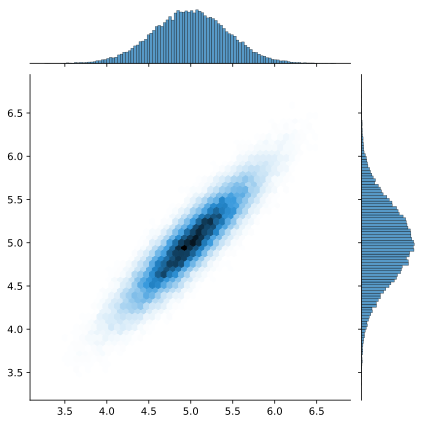

In [ ]:
burn = 500
x, y = zip(*samples[burn:])
sns.jointplot(x=x, y=y, kind = 'hex')
plt.show()

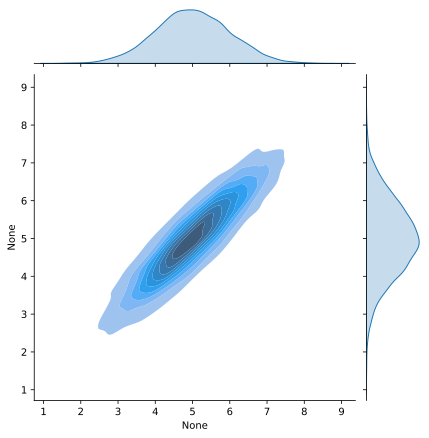

In [ ]:
samples = np.random.multivariate_normal(mus, sigmas, 10000)
sns.jointplot(x=samples[:,0], y=samples[:,1], kind='kde', fill=True)
plt.show()